# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?

**For the purposes of this lab you MUST use the model building techniques we covered in class.  Failure to do so will automatically result in a 20 point deduction.  I really want you to think about what you are doing and not just paste what you get from ChatGPT (which will often NOT do the correct thing by default).**



In [146]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split


df = pd.read_csv("Employee_productivity.csv")
print(df.head())
print(df.info())
                 



   HoursWorked  FocusScore  ProductivityScore   Department  YearsAtCompany  \
0         42.4         6.3            3127.96  Engineering              17   
1         34.0         7.2            4742.60           HR               8   
2         47.2         5.6            2044.73        Sales              15   
3         38.4         9.0            5818.92           HR               5   
4         36.4         2.5            1841.31        Sales               9   

   TeamMeetingsPerWeek    DeskLocation  
0                    0       Open Plan  
1                    6  Private Office  
2                    3          Remote  
3                    6  Private Office  
4                    6          Remote  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   HoursWorked          300 non-null    float64
 1   FocusScore           300 n

                            OLS Regression Results                            
Dep. Variable:      ProductivityScore   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.1227
Date:                Mon, 25 May 2026   Prob (F-statistic):              0.726
Time:                        23:18:53   Log-Likelihood:                -2564.1
No. Observations:                 300   AIC:                             5132.
Df Residuals:                     298   BIC:                             5140.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           3154.6734    136.338     23.

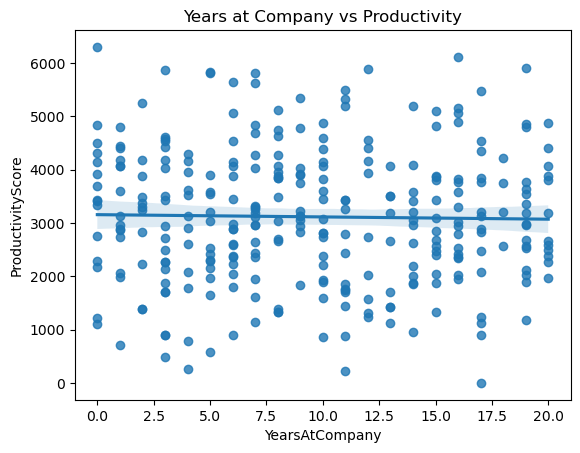

In [147]:
X = sm.add_constant(df['YearsAtCompany'])
y = df['ProductivityScore']

model = sm.OLS(y,X).fit()

print(model.summary())

sns.regplot(x='YearsAtCompany',y='ProductivityScore', data=df)
plt.title("Years at Company vs Productivity")
plt.show()

                            OLS Regression Results                            
Dep. Variable:      ProductivityScore   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.7768
Date:                Mon, 25 May 2026   Prob (F-statistic):              0.379
Time:                        23:18:54   Log-Likelihood:                -2563.7
No. Observations:                 300   AIC:                             5131.
Df Residuals:                     298   BIC:                             5139.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        3638.4153    599.175      6.072      

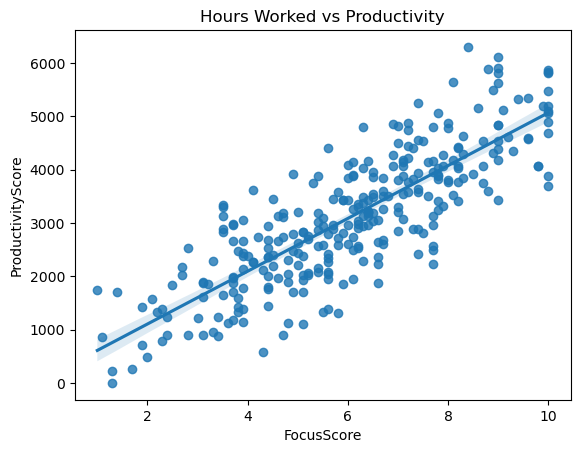

In [148]:
X = sm.add_constant(df['HoursWorked'])
y = df['ProductivityScore']

model = sm.OLS(y,X).fit()

print(model.summary())
sns.regplot(x='FocusScore',y='ProductivityScore', data=df)
plt.title("Hours Worked vs Productivity")
plt.show()

                            OLS Regression Results                            
Dep. Variable:      ProductivityScore   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     626.6
Date:                Mon, 25 May 2026   Prob (F-statistic):           3.02e-75
Time:                        23:18:55   Log-Likelihood:                -2394.3
No. Observations:                 300   AIC:                             4793.
Df Residuals:                     298   BIC:                             4800.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        114.3813    126.657      0.903      0.3

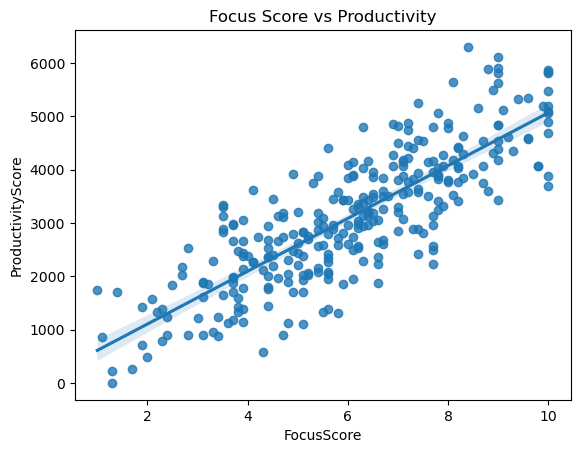

In [149]:
X = sm.add_constant(df['FocusScore'])
y = df['ProductivityScore']

model = sm.OLS(y,X).fit()

print(model.summary())

sns.regplot(x='FocusScore',y='ProductivityScore', data=df)
plt.title("Focus Score vs Productivity")
plt.show()

Hours worked and Years at company both have a 0 R2, with negative adjusted R2 numbers score meaning that they are irrelevant when compared next to productivity score. 

                            OLS Regression Results                            
Dep. Variable:      ProductivityScore   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     17.09
Date:                Mon, 25 May 2026   Prob (F-statistic):           4.63e-05
Time:                        23:18:56   Log-Likelihood:                -2555.8
No. Observations:                 300   AIC:                             5116.
Df Residuals:                     298   BIC:                             5123.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                3611.2745    

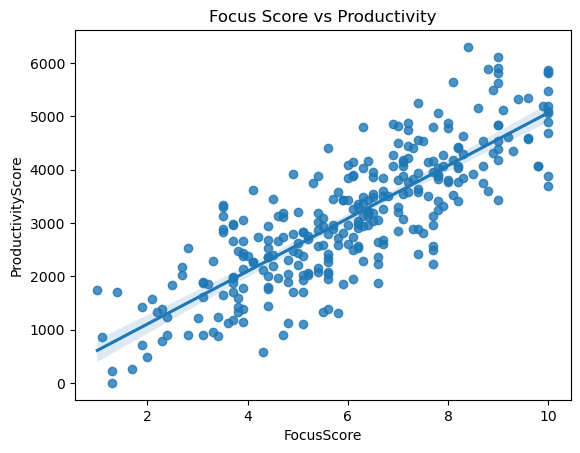

In [150]:
X = sm.add_constant(df['TeamMeetingsPerWeek'])
y = df['ProductivityScore']

model = sm.OLS(y,X).fit()

print(model.summary())

sns.regplot(x='FocusScore',y='ProductivityScore', data=df)
plt.title("Focus Score vs Productivity")
plt.show()


                            OLS Regression Results                            
Dep. Variable:      ProductivityScore   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.676
Method:                 Least Squares   F-statistic:                     313.3
Date:                Mon, 25 May 2026   Prob (F-statistic):           6.79e-74
Time:                        23:18:57   Log-Likelihood:                -2393.9
No. Observations:                 300   AIC:                             4794.
Df Residuals:                     297   BIC:                             4805.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  21.3955    

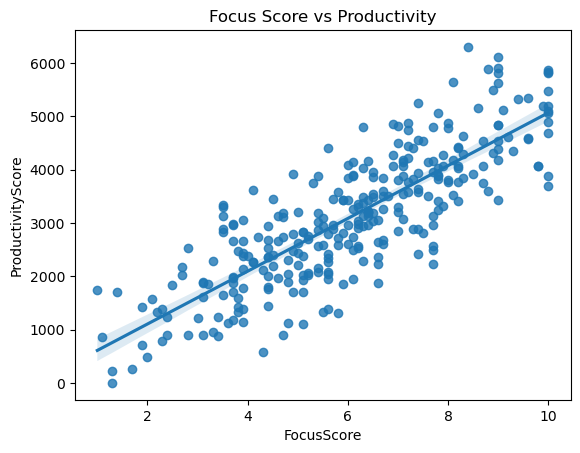

In [151]:
X = sm.add_constant(df[['FocusScore','TeamMeetingsPerWeek']])
y = df['ProductivityScore']

model = sm.OLS(y,X).fit()

print(model.summary())

sns.regplot(x='FocusScore',y='ProductivityScore', data=df)
plt.title("Focus Score vs Productivity")
plt.show()


In [152]:
print(df['DeskLocation'].unique())

['Open Plan' 'Private Office' 'Remote']


In [153]:
df['DeskLocation'] = df['DeskLocation'].map({
    'Open Plan': 0,
    'Private Office': 1,
    'Remote': 2
})

In [154]:
print(df['DeskLocation'].head())
print(df['DeskLocation'].dtype)

0    0
1    1
2    2
3    1
4    2
Name: DeskLocation, dtype: int64
int64


In [155]:
X = sm.add_constant(df[['FocusScore', 'DeskLocation']])
y = df['ProductivityScore']

model = sm.OLS(y,X).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:      ProductivityScore   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.680
Method:                 Least Squares   F-statistic:                     318.3
Date:                Mon, 25 May 2026   Prob (F-statistic):           1.35e-74
Time:                        23:19:01   Log-Likelihood:                -2392.3
No. Observations:                 300   AIC:                             4791.
Df Residuals:                     297   BIC:                             4802.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          156.0322    127.784      1.221   

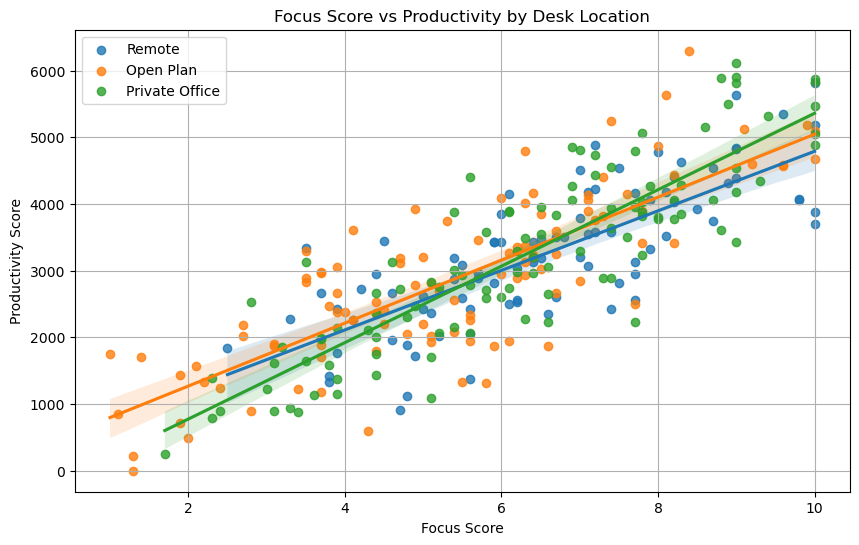

In [156]:
plt.figure(figsize=(10, 6))

sns.regplot(
    x='FocusScore',
    y='ProductivityScore',
    data=df[df['DeskLocation'] == 2],
    label='Remote'
)

sns.regplot(
    x='FocusScore',
    y='ProductivityScore',
    data=df[df['DeskLocation'] == 0],
    label='Open Plan'
)

sns.regplot(
    x='FocusScore',
    y='ProductivityScore',
    data=df[df['DeskLocation'] == 1],
    label='Private Office'
)

plt.title('Focus Score vs Productivity by Desk Location')

plt.xlabel('Focus Score')
plt.ylabel('Productivity Score')

plt.legend()

plt.grid(True)

plt.show()

In [157]:
print(df['Department'].unique())

['Engineering' 'HR' 'Sales' 'Marketing']


In [158]:
df['Department'] = df['Department'].map({
    'Engineering':0,
    'HR':1,
    'Sales':2,
    'Marketing':3
})


In [161]:
X = sm.add_constant(df[['FocusScore', 'Department']])
y = df['ProductivityScore']

model = sm.OLS(y,X).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:      ProductivityScore   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.676
Method:                 Least Squares   F-statistic:                     313.4
Date:                Mon, 25 May 2026   Prob (F-statistic):           6.56e-74
Time:                        23:21:29   Log-Likelihood:                -2393.9
No. Observations:                 300   AIC:                             4794.
Df Residuals:                     297   BIC:                             4805.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        161.2832    137.926      1.169      0.2

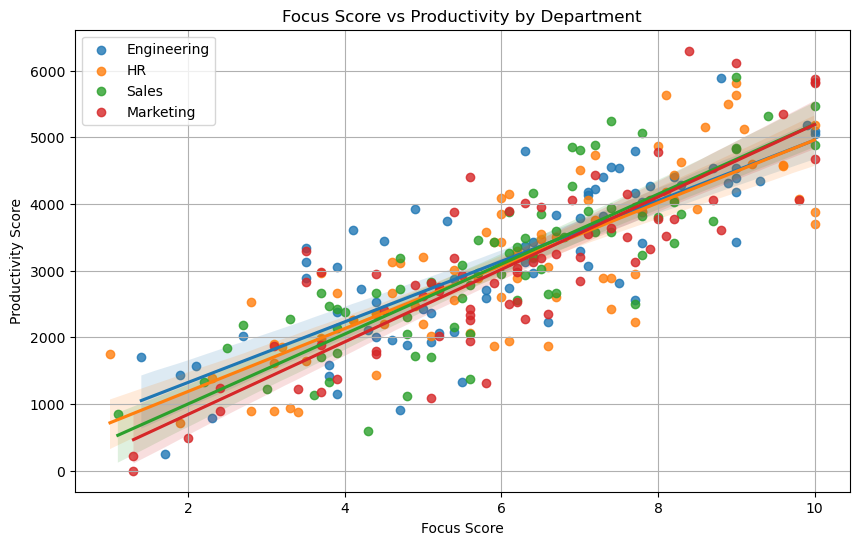

In [162]:
plt.figure(figsize=(10, 6))

sns.regplot(
    x='FocusScore',
    y='ProductivityScore',
    data=df[df['Department'] == 0],
    label='Engineering'
)

sns.regplot(
    x='FocusScore',
    y='ProductivityScore',
    data=df[df['Department'] == 1],
    label='HR'
)

sns.regplot(
    x='FocusScore',
    y='ProductivityScore',
    data=df[df['Department'] == 2],
    label='Sales'
)

sns.regplot(
    x='FocusScore',
    y='ProductivityScore',
    data=df[df['Department'] == 3],
    label='Marketing'
)


plt.title('Focus Score vs Productivity by Department')

plt.xlabel('Focus Score')
plt.ylabel('Productivity Score')

plt.legend()

plt.grid(True)

plt.show()

In [163]:
X = sm.add_constant(df[['FocusScore', 'Department','DeskLocation']])
y = df['ProductivityScore']

model = sm.OLS(y,X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      ProductivityScore   R-squared:                       0.683
Model:                            OLS   Adj. R-squared:                  0.680
Method:                 Least Squares   F-statistic:                     212.3
Date:                Mon, 25 May 2026   Prob (F-statistic):           1.85e-73
Time:                        23:21:30   Log-Likelihood:                -2391.9
No. Observations:                 300   AIC:                             4792.
Df Residuals:                     296   BIC:                             4807.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          204.3315    138.941      1.471   